# Session 2 — Nettoyage des données Airbnb NYC 2019

**Dataset :** New York City Airbnb Open Data 2019 (Kaggle)
**Objectif :** Produire un dataset propre, exploitable pour la modélisation
**Source :** https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data

## Plan
1. Diagnostic initial
2. Valeurs manquantes
3. Types de données
4. Doublons et incohérences
5. Outliers
6. Texte sale
7. Sauvegarde du dataset propre

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# réglages d'affichage
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('data/AB_NYC_2019.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [5]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [6]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

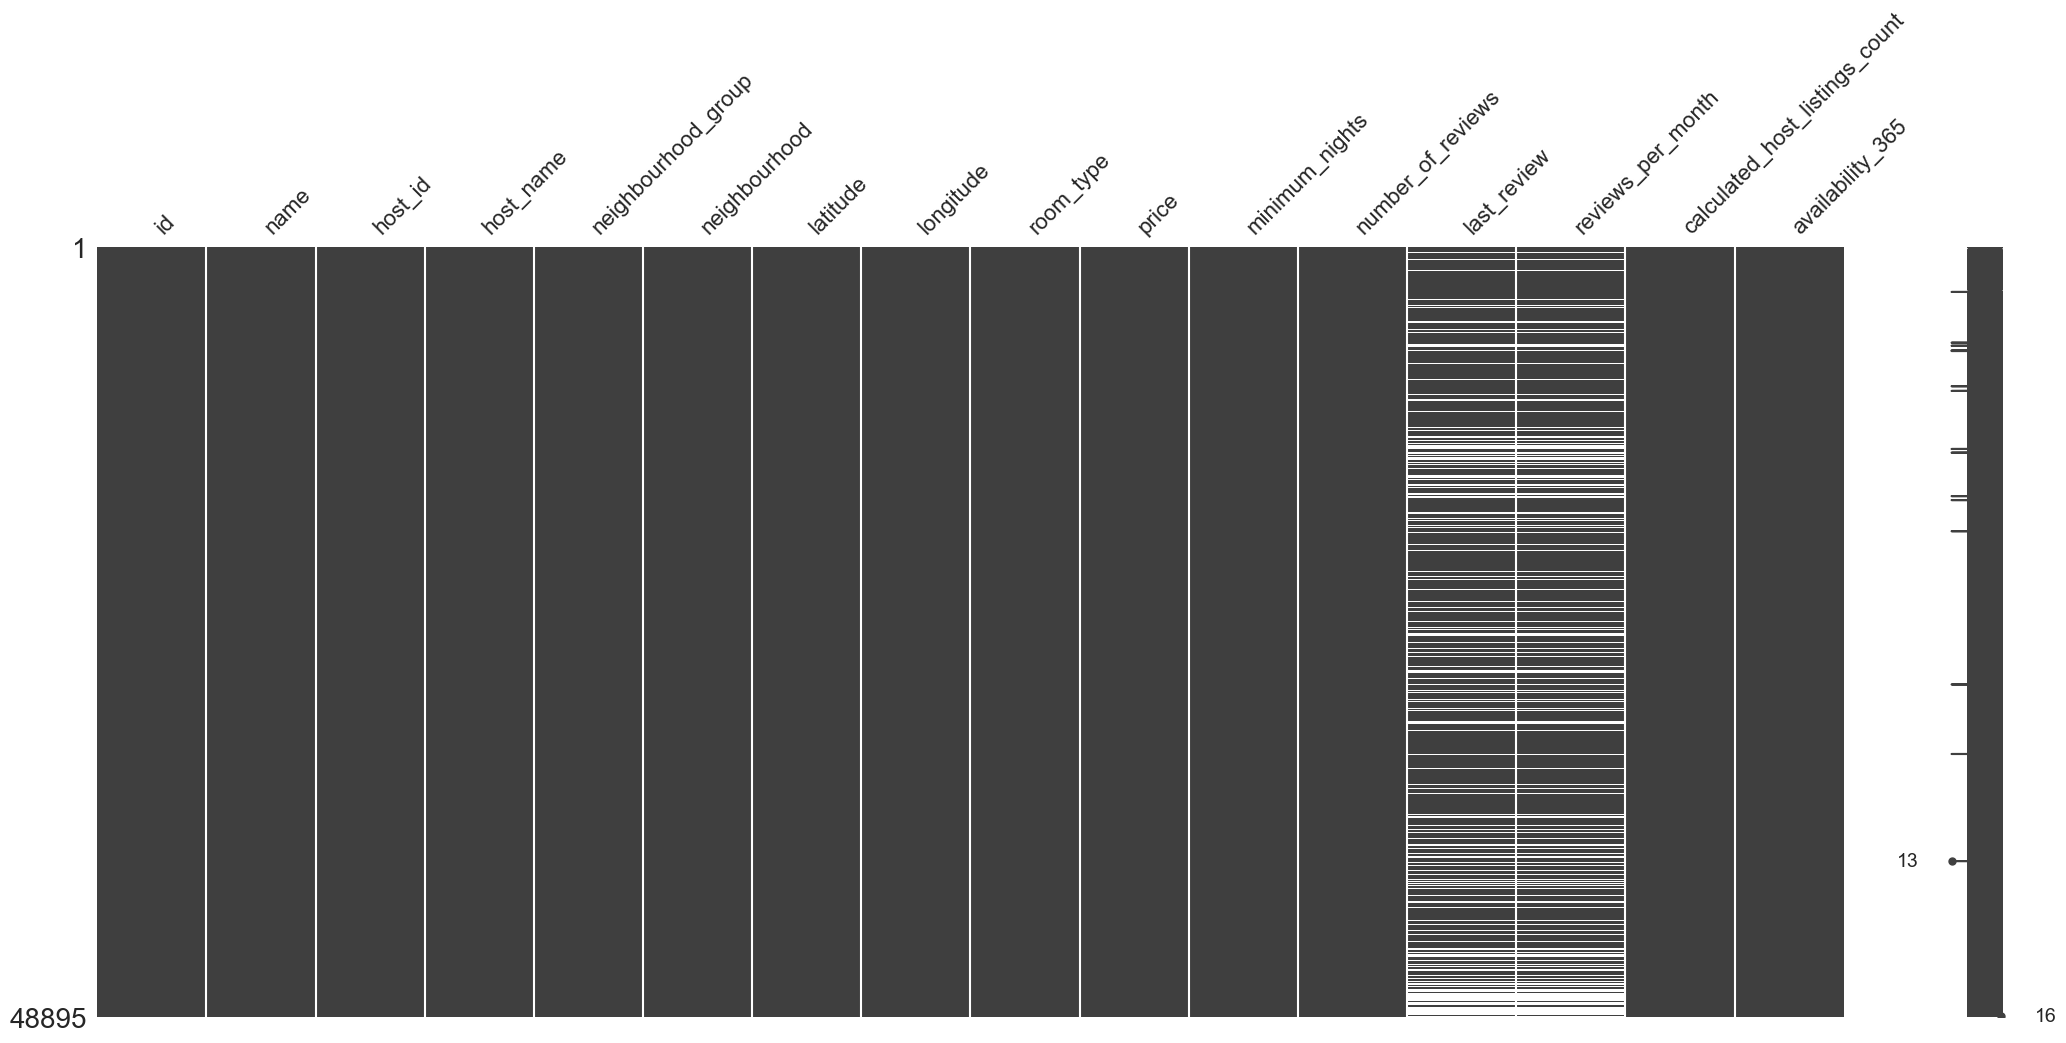

In [7]:
msno.matrix(df)
plt.show()

In [9]:
df[df['reviews_per_month'].isnull()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
19,7750,Huge 2 BR Upper East Cental Park,17985,Sing,Manhattan,East Harlem,40.79685,-73.94872,Entire home/apt,190,7,0,NaN,NaN,2,249
26,8700,Magnifique Suite au N de Manhattan - vue Cloitres,26394,Claude & Sophie,Manhattan,Inwood,40.86754,-73.92639,Private room,80,4,0,NaN,NaN,1,0
36,11452,Clean and Quiet in Brooklyn,7355,Vt,Brooklyn,Bedford-Stuyvesant,40.68876,-73.94312,Private room,35,60,0,NaN,NaN,1,365
38,11943,Country space in the city,45445,Harriet,Brooklyn,Flatbush,40.63702,-73.96327,Private room,150,1,0,NaN,NaN,1,365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [10]:
df[df['reviews_per_month'].isnull()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
19,7750,Huge 2 BR Upper East Cental Park,17985,Sing,Manhattan,East Harlem,40.79685,-73.94872,Entire home/apt,190,7,0,NaN,NaN,2,249
26,8700,Magnifique Suite au N de Manhattan - vue Cloitres,26394,Claude & Sophie,Manhattan,Inwood,40.86754,-73.92639,Private room,80,4,0,NaN,NaN,1,0
36,11452,Clean and Quiet in Brooklyn,7355,Vt,Brooklyn,Bedford-Stuyvesant,40.68876,-73.94312,Private room,35,60,0,NaN,NaN,1,365
38,11943,Country space in the city,45445,Harriet,Brooklyn,Flatbush,40.63702,-73.96327,Private room,150,1,0,NaN,NaN,1,365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [12]:
df[df['reviews_per_month'].isnull()]['number_of_reviews'].describe()

count    10052.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: number_of_reviews, dtype: float64

In [14]:
df['reviews_per_month']=df['reviews_per_month'].fillna(0)

In [16]:
df['reviews_per_month'].isnull().sum()

np.int64(0)

In [20]:
# last_review manque pour les mêmes lignes (jamais d'avis)
# On peut soit :
#   - garder NaN (sera traité comme date manquante)
#   - créer une colonne booléenne "has_been_reviewed"
df['has_been_reviewed'] = df['last_review'].notna()

# Pour la modélisation, on convertira plus tard last_review en feature numérique
# (par exemple : nombre de jours depuis le dernier avis)

In [18]:
# Quelques NaN seulement, on remplace par "Unknown"
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

In [21]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
has_been_reviewed                     0
dtype: int64

In [22]:
df.dtypes

id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
has_been_reviewed                    bool
dtype: object

In [23]:
# to_datetime convertit en pandas datetime
# errors='coerce' transforme les valeurs invalides en NaT (Not a Time)
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

print(df['last_review'].dtype)
print(df['last_review'].describe())

datetime64[us]
count                         38843
mean     2018-10-04 01:47:23.910099
min             2011-03-28 00:00:00
25%             2018-07-08 00:00:00
50%             2019-05-19 00:00:00
75%             2019-06-23 00:00:00
max             2019-07-08 00:00:00
Name: last_review, dtype: object


In [24]:
# on créera ces features en Session 3, mais on peut déjà vérifier que ça marche :
print("Plage temporelle :", df['last_review'].min(), "→", df['last_review'].max())

Plage temporelle : 2011-03-28 00:00:00 → 2019-07-08 00:00:00


In [25]:
df['neighbourhood_group'] = df['neighbourhood_group'].astype('category')
df['room_type'] = df['room_type'].astype('category')

# vérifier les modalités
print(df['neighbourhood_group'].value_counts())
print()
print(df['room_type'].value_counts())

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


In [27]:
# pour chaque colonne 'object', vérifier si elle pourrait être numérique
for col in df.select_dtypes(include=['str']).columns:
    try:
        pd.to_numeric(df[col])
        print(f"⚠️ {col} pourrait être numérique")
    except (ValueError, TypeError):
        pass  # vraiment du texte, OK

In [28]:
# doublons sur TOUTES les colonnes
print(f"Doublons stricts : {df.duplicated().sum()}")

# doublons sur la colonne id (qui devrait être unique)
print(f"id dupliqués : {df['id'].duplicated().sum()}")

Doublons stricts : 0
id dupliqués : 0


In [29]:
# combien d'annonces avec prix 0 ?
zero_price = (df['price'] == 0).sum()
print(f"Annonces avec prix 0 : {zero_price}")

# les regarder
df[df['price'] == 0].head()

Annonces avec prix 0 : 11


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,has_been_reviewed
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28,True
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2019-06-24,2.56,4,127,True
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0,True
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0,True
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,2018-01-02,0.15,1,73,True


In [30]:
# vérifier la cohérence : si number_of_reviews == 0, last_review doit être NaT
incoherent = df[(df['number_of_reviews'] == 0) & (df['last_review'].notna())]
print(f"Incohérences : {len(incoherent)}")
# Sur ce dataset, il devrait y en avoir 0

Incohérences : 0


In [31]:
# NYC est approximativement entre :
# latitude : 40.5 — 40.95
# longitude : -74.3 — -73.7
out_of_nyc = df[
    (df['latitude'] < 40.5) | (df['latitude'] > 40.95) |
    (df['longitude'] < -74.3) | (df['longitude'] > -73.7)
]
print(f"Hors zone NYC : {len(out_of_nyc)}")

Hors zone NYC : 1


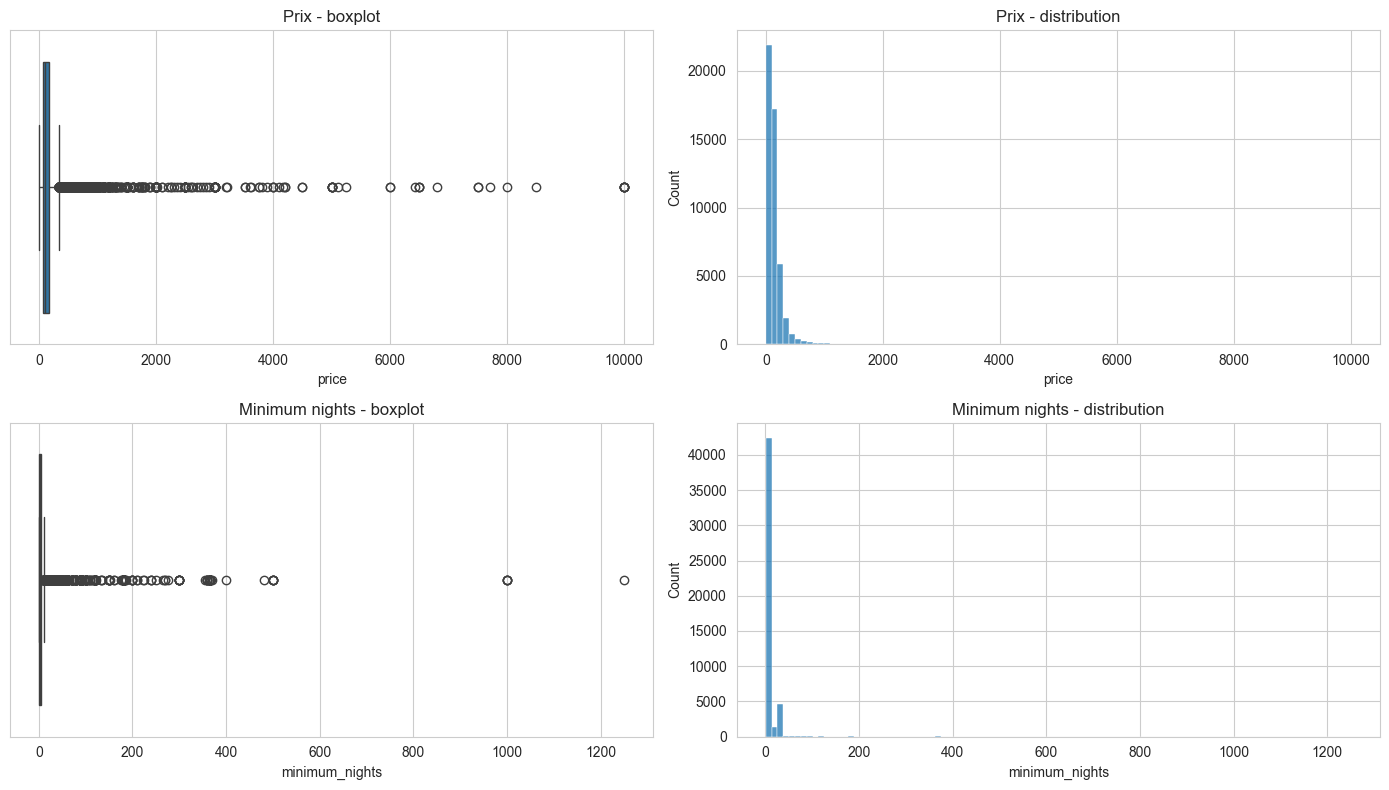

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.boxplot(x=df['price'], ax=axes[0, 0])
axes[0, 0].set_title('Prix - boxplot')

sns.histplot(df['price'], bins=100, ax=axes[0, 1])
axes[0, 1].set_title('Prix - distribution')

sns.boxplot(x=df['minimum_nights'], ax=axes[1, 0])
axes[1, 0].set_title('Minimum nights - boxplot')

sns.histplot(df['minimum_nights'], bins=100, ax=axes[1, 1])
axes[1, 1].set_title('Minimum nights - distribution')

plt.tight_layout()
plt.show()

In [33]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1 : {Q1}, Q3 : {Q3}, IQR : {IQR}")
print(f"Bornes : [{lower}, {upper}]")
print(f"Outliers IQR : {((df['price'] < lower) | (df['price'] > upper)).sum()}")

Q1 : 69.0, Q3 : 175.0, IQR : 106.0
Bornes : [-90.0, 334.0]
Outliers IQR : 2972


In [34]:
before = len(df)
df = df[(df['price'] >= 10) & (df['price'] <= 1000)].copy()
print(f"Lignes supprimées (prix extrême) : {before - len(df)}")

Lignes supprimées (prix extrême) : 250


In [35]:
before = len(df)
df = df[df['minimum_nights'] <= 365].copy()
print(f"Lignes supprimées (min_nights extrême) : {before - len(df)}")

Lignes supprimées (min_nights extrême) : 14


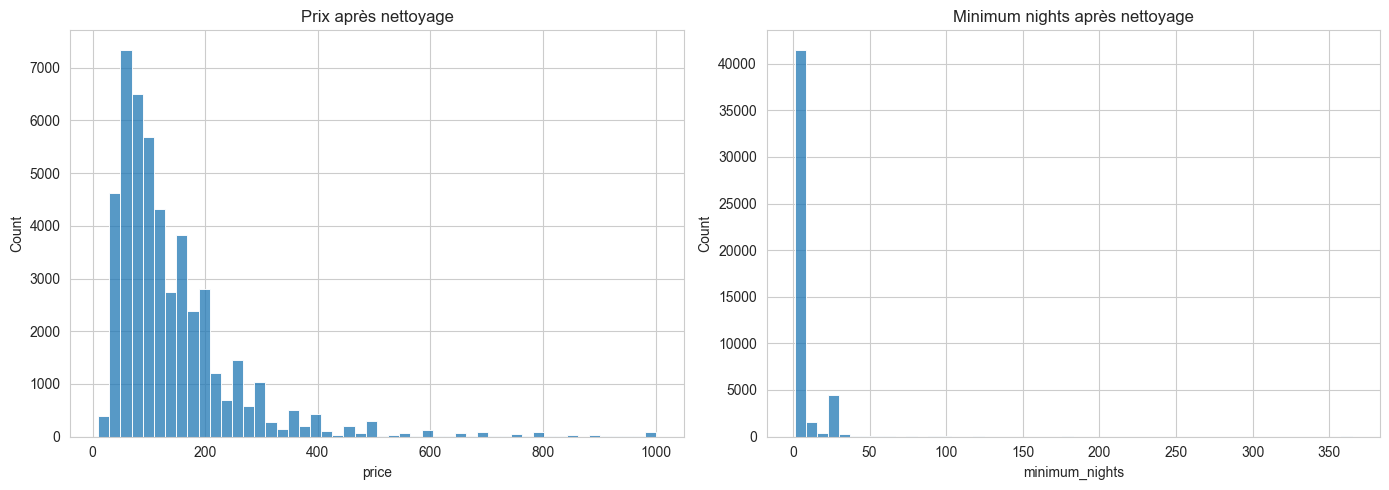

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['price'], bins=50, ax=axes[0])
axes[0].set_title('Prix après nettoyage')

sns.histplot(df['minimum_nights'], bins=50, ax=axes[1])
axes[1].set_title('Minimum nights après nettoyage')

plt.tight_layout()
plt.show()

In [37]:
# pour neighbourhood, on s'attend à des noms propres bien formés
print(f"Nombre de quartiers uniques : {df['neighbourhood'].nunique()}")

# exemple : quelques quartiers
df['neighbourhood'].value_counts().head(20)

Nombre de quartiers uniques : 221


neighbourhood
Williamsburg          3908
Bedford-Stuyvesant    3699
Harlem                2651
Bushwick              2460
Hell's Kitchen        1951
Upper West Side       1948
East Village          1841
Upper East Side       1785
Crown Heights         1560
Midtown               1525
East Harlem           1113
Greenpoint            1113
Chelsea               1100
Lower East Side        907
Washington Heights     899
Astoria                896
West Village           754
Financial District     742
Flatbush               620
Clinton Hill           569
Name: count, dtype: int64

In [38]:
# strip() enlève les espaces de début et de fin
# title() met une majuscule à chaque mot
df['neighbourhood'] = df['neighbourhood'].str.strip().str.title()

# pour name : on standardise mais on garde la casse originale (titres d'annonce)
df['name'] = df['name'].str.strip()

# pour host_name : capitaliser correctement
df['host_name'] = df['host_name'].str.strip().str.title()

In [39]:
# un quartier qui apparaît une seule fois est suspect
rare_neighborhoods = df['neighbourhood'].value_counts()
suspicious = rare_neighborhoods[rare_neighborhoods == 1]
print(f"Quartiers à 1 seule annonce : {len(suspicious)}")

# pour ce dataset c'est OK : NYC a beaucoup de quartiers très spécifiques
# mais sur un autre dataset, ce serait souvent des fautes de frappe à 

Quartiers à 1 seule annonce : 6


In [40]:
# exemple générique pour nettoyer les caractères de contrôle
# (à appliquer sur des datasets vraiment sales)
# df['col'] = df['col'].str.replace(r'\s+', ' ', regex=True).str.strip()

# pour notre dataset Airbnb, le nettoyage basique ci-dessus suffit

## Résumé du nettoyage

| Étape | Action | Lignes supprimées |
|-------|--------|------------------|
| Prix == 0 | Supprimées | XX |
| Prix > 1000 | Supprimées | XX |
| min_nights > 365 | Supprimées | XX |

| Étape | Colonne | Action |
|-------|---------|--------|
| NaN | reviews_per_month | Remplacé par 0 |
| NaN | name, host_name | Remplacé par "Unknown" |
| NaN | last_review | Conservé (NaT) + colonne booléenne ajoutée |
| Type | last_review | Converti en datetime |
| Type | neighbourhood_group, room_type | Convertis en category |
| Texte | neighbourhood | strip + title |
| Texte | name, host_name | strip (+ title pour host_name) |

**Dataset final :** XX lignes, XX colonnes

In [41]:
print(f"Shape final : {df.shape}")
print(f"\nTypes :")
print(df.dtypes)
print(f"\nValeurs manquantes restantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape final : (48631, 17)

Types :
id                                         int64
name                                         str
host_id                                    int64
host_name                                    str
neighbourhood_group                     category
neighbourhood                                str
latitude                                 float64
longitude                                float64
room_type                               category
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[us]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
has_been_reviewed                           bool
dtype: object

Valeurs manquantes restantes :
last_review    9911
dtype: int64
